In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=200)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=200)

In [4]:
model = keras.Sequential([
    keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    keras.layers.LSTM(64),
    keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7805 - loss: 0.4517 - val_accuracy: 0.8574 - val_loss: 0.3434
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8964 - loss: 0.2631 - val_accuracy: 0.8698 - val_loss: 0.3175
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9350 - loss: 0.1750 - val_accuracy: 0.8608 - val_loss: 0.3294
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9495 - loss: 0.1370 - val_accuracy: 0.8224 - val_loss: 0.4355
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9649 - loss: 0.1006 - val_accuracy: 0.8552 - val_loss: 0.4212


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8523 - loss: 0.4357
Test Accuracy: 0.8522800207138062


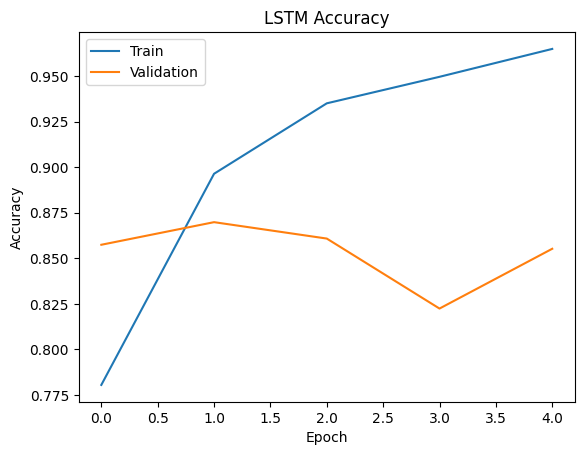

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# 📘 Cell-wise Explanation of RNN/LSTM (IMDB Dataset)

### 🔹 Cell 1: Import Libraries

Imports TensorFlow/Keras for building the model, NumPy for computations, and Matplotlib for visualization.

---

### 🔹 Cell 2: Load Dataset

Loads IMDB movie review dataset for sentiment classification.
Only the top 10,000 most frequent words are considered.

---

### 🔹 Cell 3: Pad Sequences

Ensures all input sequences have the same length (200 words).
Short sequences are padded, and long ones are truncated.

---

### 🔹 Cell 4: Build LSTM Model

Defines the architecture:

* Embedding layer converts words into dense vectors
* LSTM layer captures sequential dependencies
* Dense layer with sigmoid activation outputs sentiment (0 or 1)

---

### 🔹 Cell 5: Compile Model

Configures model training using:

* Adam optimizer
* Binary crossentropy loss
* Accuracy metric

---

### 🔹 Cell 6: Train Model

Trains the model for 5 epochs with batch size 64.
Validation split is used to monitor performance.

---

### 🔹 Cell 7: Evaluate Model

Evaluates performance on unseen test data and prints accuracy.

---

### 🔹 Cell 8: Plot Accuracy

Plots training and validation accuracy to analyze learning behavior.

---

# ✅ Conclusion

The LSTM-based RNN successfully captured sequential patterns in text data and performed sentiment classification with good accuracy.


# 📊 Dataset Description: IMDB Movie Review Dataset

### 📌 Description

The IMDB dataset is a collection of movie reviews labeled by sentiment (positive or negative). It is widely used in Natural Language Processing (NLP) tasks such as sentiment analysis and sequence modeling using RNN/LSTM.

### 📊 Features

* Text data consisting of **movie reviews**
* Reviews are preprocessed into **integer sequences**, where each integer represents a word index
* Vocabulary is limited to the **top 10,000 most frequent words**
* Input sequences are padded to ensure uniform length

### 🎯 Target Variable

* Binary sentiment label:

  * **0 → Negative review**
  * **1 → Positive review**
* Type: **Binary classification**

### 📦 Dataset Size

* Training samples: **25,000 reviews**
* Testing samples: **25,000 reviews**
* Total samples: **50,000 reviews**

### ⭐ Key Characteristics

* Balanced dataset (equal positive and negative samples)
* Variable-length text sequences (handled using padding)
* Captures sequential dependencies in language
* Ideal for testing RNN and LSTM models
